# Clustering -  Empleados

1. Preparación de datos: variables numéricas se deben normalizar y variables categóricas se crean dummies
2. Aprendizaje del Modelo: Kmeans, método del codo
3. Evaluación del Modelo: Inertia, silueta
4. Perfilamiento: Descripción de centroides



In [38]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica



In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Preparación de Datos

* Previa limpieza de atípicos, nulos y altas correlaciones









In [40]:
# Se cargan los datos
df = pd.read_excel("Empleados.xlsx",sheet_name="Empleados") #Cargar datos en excel
df.head() #muestras los 5 primeros registros

,Sueldo,Casado,Carro,Hijos,Casa,Sindicato,Incapacidades,Antiguedad,Sexo
0,4100000,Sí,No,0,Alquiler,No,7,15,H
1,5600000,No,Sí,1,Alquiler,Sí,3,3,M
2,5200000,Sí,Sí,2,Prop,Sí,5,10,H
3,7100000,Sí,Sí,1,Alquiler,No,15,7,M
4,4200000,Sí,Sí,0,Prop,Sí,1,6,H


In [41]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sueldo         270 non-null    int64 
 1   Casado         270 non-null    object
 2   Carro          270 non-null    object
 3   Hijos          270 non-null    int64 
 4   Casa           270 non-null    object
 5   Sindicato      270 non-null    object
 6   Incapacidades  270 non-null    int64 
 7   Antiguedad     270 non-null    int64 
 8   Sexo           270 non-null    object
dtypes: int64(4), object(5)
memory usage: 19.1+ KB


In [42]:
#Corregir tipos de datos
df['Casado']=df['Casado'].astype('category')
df['Carro']=df['Carro'].astype('category')
df['Casa']=df['Casa'].astype('category')
df['Sindicato']=df['Sindicato'].astype('category')
df['Sexo']=df['Sexo'].astype('category')
#...

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Sueldo         270 non-null    int64   
 1   Casado         270 non-null    category
 2   Carro          270 non-null    category
 3   Hijos          270 non-null    int64   
 4   Casa           270 non-null    category
 5   Sindicato      270 non-null    category
 6   Incapacidades  270 non-null    int64   
 7   Antiguedad     270 non-null    int64   
 8   Sexo           270 non-null    category
dtypes: category(5), int64(4)
memory usage: 10.5 KB


In [43]:
#Descripción estadística de variables numéricas
df.describe()

,Sueldo,Hijos,Incapacidades,Antiguedad
count,2.700000e+02,270.000000,270.000000,270.000000
mean,5.605185e+06,0.733333,5.266667,8.200000
std,1.347271e+06,0.999628,6.877797,5.265868
min,2.000000e+06,0.000000,0.000000,1.000000
25%,4.600000e+06,0.000000,1.000000,5.000000
50%,5.700000e+06,0.000000,3.000000,7.000000
75%,6.500000e+06,2.000000,7.000000,12.000000
max,9.200000e+06,3.000000,27.000000,20.000000


array([[<Axes: title={'center': 'Sueldo'}>,
        <Axes: title={'center': 'Hijos'}>],
       [<Axes: title={'center': 'Incapacidades'}>,
        <Axes: title={'center': 'Antiguedad'}>]], dtype=object)

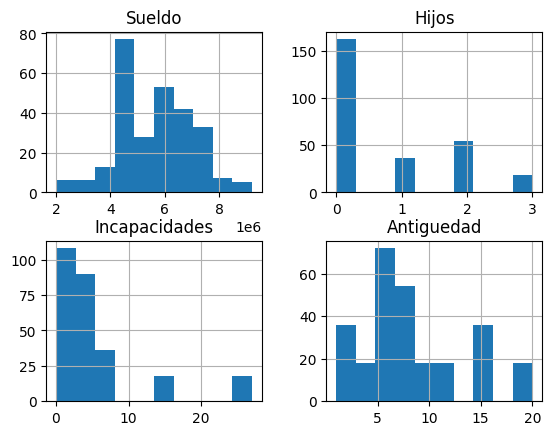

In [44]:
#Gráficar variables numéricas
df.hist()

,0
Sueldo,"Axes(0.125,0.53;0.168478x0.35)"
Hijos,"Axes(0.327174,0.53;0.168478x0.35)"
Incapacidades,"Axes(0.529348,0.53;0.168478x0.35)"
Antiguedad,"Axes(0.731522,0.53;0.168478x0.35)"


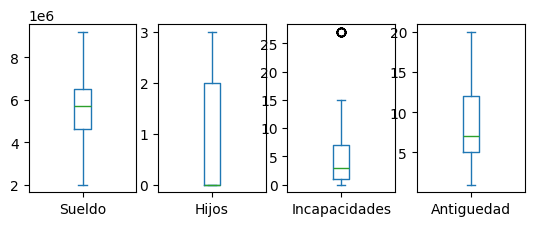

In [45]:
#Gráfico box para variables numéricas
df.plot(kind='box', subplots=True, layout=(2,4), sharex=False, sharey=False)

<Axes: xlabel='Sexo'>

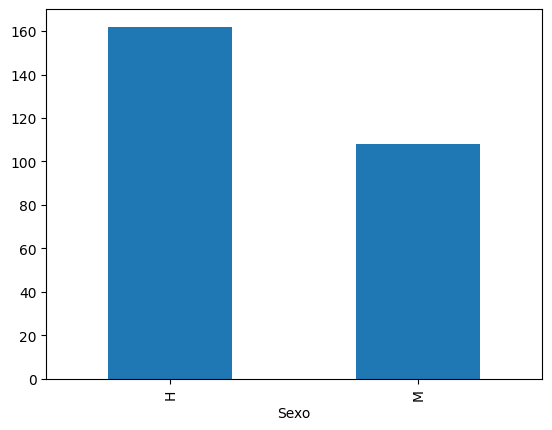

In [46]:
#Gráficas de variables categoricas juntas con etiquetas de datos
df['Sexo'].value_counts().plot(kind='bar')

<Axes: xlabel='Casado'>

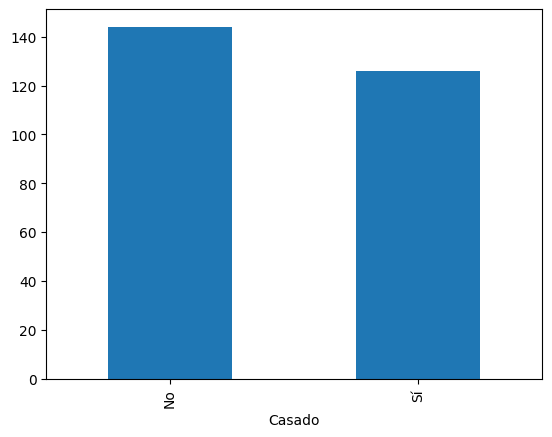

In [47]:
df['Casado'].value_counts().plot(kind='bar')



<Axes: xlabel='Carro'>

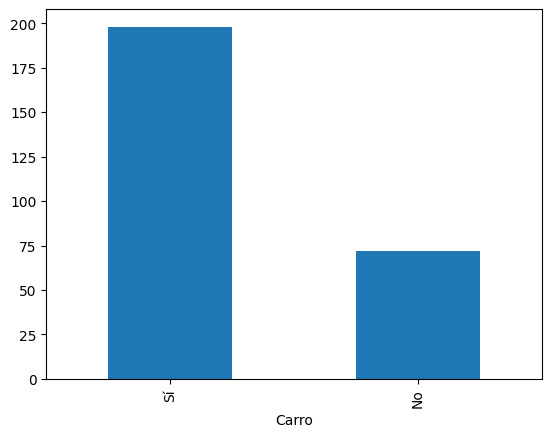

In [48]:
df['Carro'].value_counts().plot(kind='bar')


<Axes: xlabel='Casa'>

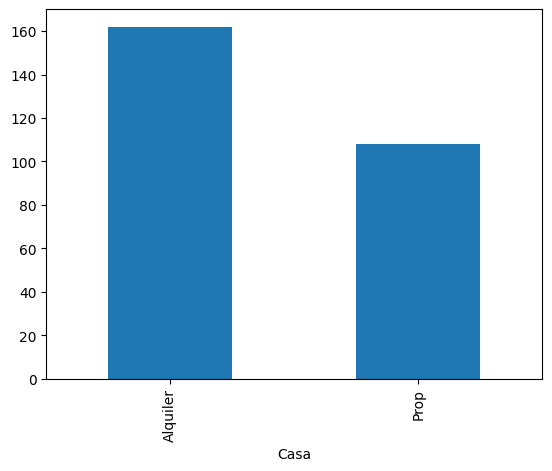

In [49]:
df['Casa'].value_counts().plot(kind='bar')

<Axes: xlabel='Sindicato'>

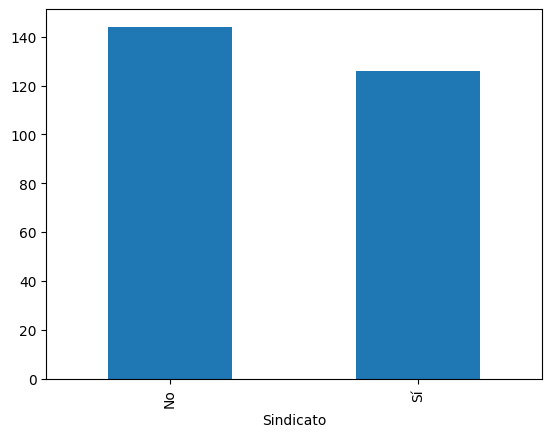

In [50]:
df['Sindicato'].value_counts().plot(kind='bar')

In [51]:
# Cargar librería para Profiling
!pip install ydata-profiling

In [52]:
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 130.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
#No se hace balanceo porque no hay variable objetivo

* Transformaciones: normalizar y crear dummies

In [55]:
#Copia de los datos
data=df.copy()


In [56]:
#Normalizacion de variables numéricas
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_a_normalizar=['Sueldo', 'Hijos',  'Incapacidades',  'Antiguedad'] #variables numéricas
min_max_scaler.fit(data[variables_a_normalizar]) #Ajuste de parámetro
data[variables_a_normalizar]= min_max_scaler.transform(data[variables_a_normalizar])
data.head()

,Sueldo,Casado,Carro,Hijos,Casa,Sindicato,Incapacidades,Antiguedad,Sexo
0,0.291667,Sí,No,0.000000,Alquiler,No,0.259259,0.736842,H
1,0.500000,No,Sí,0.333333,Alquiler,Sí,0.111111,0.105263,M
2,0.444444,Sí,Sí,0.666667,Prop,Sí,0.185185,0.473684,H
3,0.708333,Sí,Sí,0.333333,Alquiler,No,0.555556,0.315789,M
4,0.305556,Sí,Sí,0.000000,Prop,Sí,0.037037,0.263158,H


In [57]:
# Se crean dummies para las variables categóricas
data = pd.get_dummies(data, columns=['Casado', 'Carro', 'Casa', 'Sexo','Sindicato'], drop_first=True, dtype=int)
data.head()

,Sueldo,Hijos,Incapacidades,Antiguedad,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M,Sindicato_Sí
0,0.291667,0.000000,0.259259,0.736842,1,0,0,0,0
1,0.500000,0.333333,0.111111,0.105263,0,1,0,1,1
2,0.444444,0.666667,0.185185,0.473684,1,1,1,0,1
3,0.708333,0.333333,0.555556,0.315789,1,1,0,1,0
4,0.305556,0.000000,0.037037,0.263158,1,1,1,0,1


In [58]:
# Si tienen mas de 2 categorías
#data = pd.get_dummies(data, columns=['Tipo'], drop_first=False,  dtype=int) #No borra dummy

# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

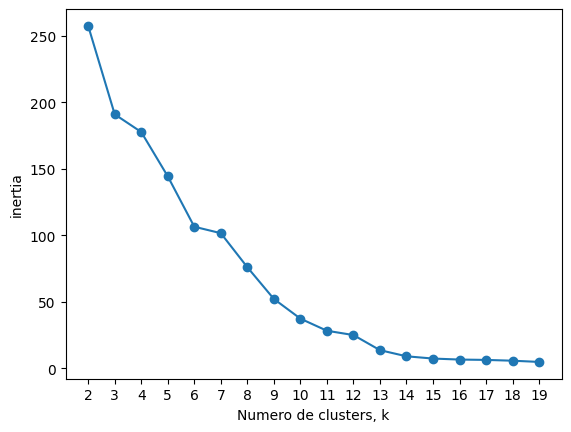

In [59]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

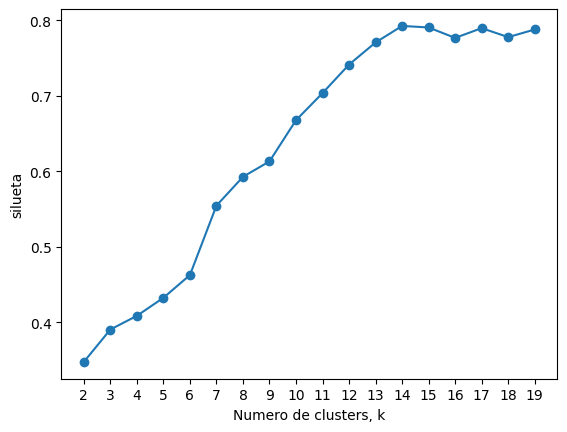

In [60]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 20) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    sil=metrics.silhouette_score(data, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [61]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=7
model = KMeans(n_clusters=k, max_iter=300)
model.fit(data) #100% datos

KMeans(n_clusters=7)

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [62]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 93.3622186555185
Silueta: 0.5267610320944285


# 4. Perfilamiento

Descripción de centroides

In [63]:
#Centroides de los cluster se convierten  en un dataframe de pandas
centroides=pd.DataFrame(model.cluster_centers_, columns=data.columns.values)
centroides.round(1)

,Sueldo,Hijos,Incapacidades,Antiguedad,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M,Sindicato_Sí
0,0.6,0.3,0.6,0.3,1.0,1.0,-0.0,1.0,0.0
1,0.5,0.0,0.0,0.2,0.0,0.7,0.0,0.0,0.7
2,0.5,0.0,0.4,0.5,0.3,-0.0,0.0,0.7,0.0
3,0.4,0.8,0.2,0.1,1.0,1.0,1.0,-0.0,0.0
4,0.5,0.3,0.1,0.4,1.0,1.0,1.0,-0.0,1.0
5,0.5,0.1,0.1,0.4,0.0,1.0,0.3,1.0,1.0
6,0.6,0.7,0.0,1.0,1.0,1.0,1.0,-0.0,0.0


In [64]:
# Se realiza una des-normalización centroides
centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])
centroides.round(0)

,Sueldo,Hijos,Incapacidades,Antiguedad,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M,Sindicato_Sí
0,5961111.0,1.0,15.0,7.0,1.0,1.0,-0.0,1.0,0.0
1,5409259.0,0.0,1.0,6.0,0.0,1.0,0.0,0.0,1.0
2,5805556.0,0.0,12.0,11.0,0.0,-0.0,0.0,1.0,0.0
3,4997222.0,2.0,5.0,3.0,1.0,1.0,1.0,-0.0,0.0
4,5269444.0,1.0,3.0,8.0,1.0,1.0,1.0,-0.0,1.0
5,5948148.0,0.0,3.0,8.0,0.0,1.0,0.0,1.0,1.0
6,6094444.0,2.0,1.0,20.0,1.0,1.0,1.0,-0.0,0.0


**DESCRIPCIÓN DE PERFILES**

PERFIL 0: Salario de 4.800.000, no hijos, incapacidades 7 dias al año, 15 años de antiguedad, casados, no carro, no casa...

PERFIL 1:

PERFIL 2:

PERFIL 3:

PERFIL 4:

PERFIL 5:

PERFIL 6:

PERFIL 7:



In [66]:
#En el dataframe original, se adiciona el cluster asignado a cada registro
df['cluster']=model.labels_
df.head()

,Sueldo,Casado,Carro,Hijos,Casa,Sindicato,Incapacidades,Antiguedad,Sexo,cluster
0,4100000,Sí,No,0,Alquiler,No,7,15,H,2
1,5600000,No,Sí,1,Alquiler,Sí,3,3,M,5
2,5200000,Sí,Sí,2,Prop,Sí,5,10,H,4
3,7100000,Sí,Sí,1,Alquiler,No,15,7,M,0
4,4200000,Sí,Sí,0,Prop,Sí,1,6,H,4


<Axes: ylabel='count'>

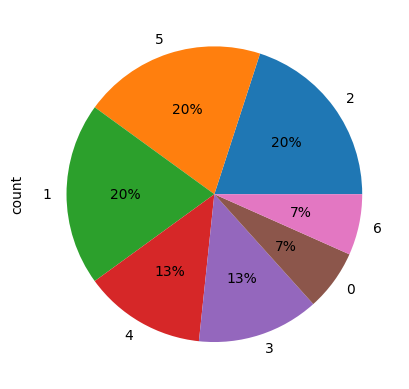

In [67]:
#Cantidad de datos en cada cluster
df["cluster"].value_counts().plot(kind='pie',autopct='%.0f%%')

In [68]:
#Almacenar resultados
df.to_excel('./resultados_Kmeans.xlsx')
centroides.to_excel('./centroides.xlsx')
